# Pipeline verification (§5.1)

Two checks that the gradient training pipeline is implemented correctly:

1. **GT-init convergence**: initialise gradient training at the ground-truth parameters. A correct optimiser holds GT to numerical precision; a buggy one drifts.
2. **Wall-time scaling**: time forward and forward+backward simulations as `T_MAX_MS` increases. A correct JAX-compiled scan scales linearly with sequence length; a graph that has been optimised away is constant.

If both checks pass, downstream negative results (gradient methods losing to random search) are a property of the loss landscape, not the implementation.

In [1]:
import logging
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from jax import config
config.update('jax_platform_name', 'cpu')

# Trainer logs via `logging`, not `print`. Jupyter doesn't route INFO records to
# cell output by default, so verbose=True looks silent. Configure once here.
logging.basicConfig(level=logging.INFO, format='%(message)s', force=True)
logging.getLogger('ADoptEX.training.trainer').setLevel(logging.INFO)

from ADoptEX.core.parameters import NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_jaxley
from ADoptEX.loss import extract_experimental_features, make_guarino_loss_fn, make_mse_loss_fn, make_van_rossum_loss_fn, MSELossConfig, VanRossumLossConfig, GuarinoLossConfig
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

## 1. GT-init convergence

Run grad_guarino starting from `NAUD_PARAMETERS['tonic']` for 200 epochs with the same hyperparameters as the matched-protocol benchmark. Plot loss, gradient norm, and per-parameter drift. The expectation: loss settles at the soft-feature numerical floor (~1e-3) and parameters stay within 1e-3 of GT in normalised units.

In [2]:
DT_MS, T_MAX_MS, STIM_DELAY_MS, STIM_DUR_MS = 0.025, 100.0, 5.0, 90.0
STIM_END_IDX = int(round((STIM_DELAY_MS + STIM_DUR_MS) / DT_MS))
STIM_START_IDX = int(round(STIM_DELAY_MS / DT_MS))
N = int(round(T_MAX_MS / DT_MS))
TRAINABLE = ['C_m', 'g_L', 'E_L', 'v_T', 'delta_T', 'v_reset']

gt = dict(NAUD_PARAMETERS['tonic'])
current = np.zeros(N)
current[STIM_START_IDX:STIM_END_IDX] = gt['I']

sim_gt = simulate_jaxley(
    params=gt, stim_current_pA=gt['I'], stim_duration_ms=STIM_DUR_MS,
    dt_ms=DT_MS, t_max_ms=T_MAX_MS, stim_delay_ms=STIM_DELAY_MS, use_surrogate=False,
)
voltage_gt = sim_gt.voltage[:N].copy()
for st in sim_gt.spike_times:
    idx = int(round(st / DT_MS))
    if 0 <= idx < N: voltage_gt[idx] = 35.0
exp_features = extract_experimental_features(
    voltage_trace=jnp.array(voltage_gt), dt_ms=DT_MS,
    stim_duration_ms=STIM_DUR_MS, stim_end_index=STIM_END_IDX,
)
print(f'GT produces {len(sim_gt.spike_times)} spikes')

INFO:2026-04-26 11:57:09,302:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
GT produces 9 spikes


use_param_transform=True with clip_to_bounds=True: sigmoid transform implicitly enforces bounds, hard clipping will be skipped.


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
mse           loss(GT) = 2.949e-01   ||grad(GT)|| = 6.429e-03
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added t

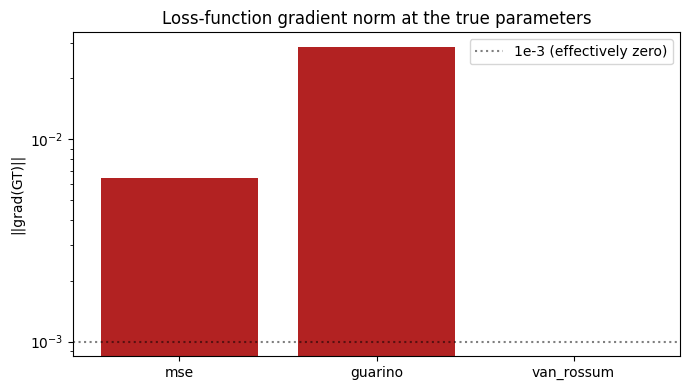

In [3]:
exp_spike_train = jnp.array(sim_gt.spikes)
cfg_eval = TrainingConfig(surrogate_type='sigmoid', surrogate_slope=5.0, use_param_transform=True)


def grad_norm(grad_dict):
    return float(jnp.sqrt(sum(float(jnp.sum(v ** 2)) for d in grad_dict for v in d.values())))


multi_results = {}
for loss_name in ['mse', 'guarino', 'van_rossum']:
    cell_, ds_, tmax_, h_ = setup_trainable_cell(
        initial_params=gt, current_trace_pA=jnp.asarray(current), v_init=voltage_gt[0],
        dt_ms=DT_MS, config=cfg_eval, trainable_params=TRAINABLE,
    )
    if loss_name == 'mse':
        lf = make_mse_loss_fn(cell=cell_, data_stimuli=ds_, t_max=tmax_, dt_ms=DT_MS, exp_voltage=jnp.array(voltage_gt), stim_end_index=STIM_END_IDX, loss_config=MSELossConfig(normalize=True))
    elif loss_name == 'guarino':
        lf = make_guarino_loss_fn(cell=cell_, data_stimuli=ds_, t_max=tmax_, dt_ms=DT_MS, exp_features=exp_features, stim_duration_ms=STIM_DUR_MS, stim_end_index=STIM_END_IDX, temperature=0.3, beta=10.0)
    else:
        lf = make_van_rossum_loss_fn(cell=cell_, data_stimuli=ds_, t_max=tmax_, dt_ms=DT_MS, exp_spike_train=exp_spike_train, stim_end_index=STIM_END_IDX, loss_config=VanRossumLossConfig(tau_ms=10.0))
    g = jax.jit(jax.value_and_grad(lf))
    l, gr = g(h_)
    multi_results[loss_name] = {'loss': float(l), 'grad_norm': grad_norm(gr)}
    print(f"{loss_name:12s}  loss(GT) = {float(l):.3e}   ||grad(GT)|| = {multi_results[loss_name]['grad_norm']:.3e}")

fig, ax = plt.subplots(figsize=(7, 4))
names = list(multi_results)
norms = [multi_results[n]['grad_norm'] for n in names]
colors = ['firebrick' if n > 1e-3 else 'steelblue' for n in norms]
bars = ax.bar(names, norms, color=colors)
ax.set_yscale('log')
ax.set_ylabel('||grad(GT)||')
ax.axhline(1e-3, color='k', linestyle=':', alpha=0.5, label='1e-3 (effectively zero)')
ax.set_title('Loss-function gradient norm at the true parameters')
for bar in bars:
    h = bar.get_height()
    # ax.text(bar.get_x() + bar.get_width() / 2, h * 1.15, f'{h:.2e}', ha='center', fontsize=9)
ax.legend()
plt.tight_layout(); plt.show()

## 1b. Cross-loss `‖∇L(θ*)‖` comparison

For a *correctly aligned* loss function, the gradient at the true parameters should be (numerically) zero — `θ*` is by definition a stationary point. A non-vanishing gradient at GT means the loss's minimum is not at GT, so gradient descent will systematically walk away.

Compute `‖∇L(θ*)‖` for MSE, Guarino, and Van Rossum side by side. If only Guarino is biased, the soft-feature design is at fault. If all three are biased, the surrogate-gradient pathway through the AdEx model itself is at fault (Klos et al. 2024's calibration argument).

`use_param_transform=False` here — we want to test the raw loss gradient, not the gradient through the sigmoid reparameterisation.

In [4]:
cfg = TrainingConfig(
    optimizer='adam', learning_rate=1e-3, n_epochs=1000,
    surrogate_type='sigmoid', surrogate_slope=5.0,
    # polyak_alpha=0.85, polyak_beta=0.8,
    grad_clip_norm=1.0,  # essential — soft-feature gradient bursts (>1e7) blow up training without this
    clip_to_bounds=False, use_param_transform=False,
    return_best=False, verbose=True, print_every=25,
)
cell, data_stimuli, t_max, handles = setup_trainable_cell(
    initial_params=gt, current_trace_pA=jnp.asarray(current), v_init=voltage_gt[0],
    dt_ms=DT_MS, config=cfg, trainable_params=TRAINABLE,
)

loss_fn = make_guarino_loss_fn(cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=DT_MS, exp_features=exp_features, stim_duration_ms=STIM_DUR_MS, stim_end_index=STIM_END_IDX, temperature=0.3, beta=10.0, validity_beta=10)

g_fn = jax.jit(jax.value_and_grad(loss_fn))
loss_at_gt, grad_at_gt = g_fn(handles)
print(f"loss(GT) = {float(loss_at_gt):.3e}")
print(f"||grad(GT)|| = {sum(float(jnp.linalg.norm(v)) for d in grad_at_gt for v in d.values()):.3e}")
for d in grad_at_gt:
    for k, v in d.items():
        print(f"  {k}: {float(v[0]):+.3e}") 

result = train(loss_fn, handles, cfg)
params_final = result.get_params_dict()
print(f'\nfinal_loss={result.final_loss:.3e}  best_loss={result.best_loss:.3e} (epoch {result.best_epoch})')
print('param drift (final - GT, normalised by bounds range):')
for p in TRAINABLE:
    b = PARAM_BOUNDS[p]
    drift = (params_final[p] - gt[p]) / (b.max - b.min)
    print(f'  {p}: {drift:+.2e}')

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6


Training: optimizer=adam lr=0.001 epochs=1000 surrogate=sigmoid slope=5.0 clip=1.0


loss(GT) = 8.229e-07
||grad(GT)|| = 5.416e-02
  capacitance: +6.249e-04
  AdEx_g_L: +4.665e-03
  AdEx_E_L: -4.269e-03
  AdEx_v_T: +1.376e-02
  AdEx_delta_T: +2.289e-02
  AdEx_v_reset: +7.948e-03


Epoch    0 | loss=0.000001 | grad_norm=2.86e-02 | C_m=199.9990, g_L=9.9990, E_L=-69.9990, v_T=-50.0010, delta_T=1.9990, v_reset=-58.0010
Epoch   25 | loss=0.043514 | grad_norm=1.61e-02 | C_m=199.9835, g_L=9.9831, E_L=-69.9835, v_T=-50.0172, delta_T=1.9828, v_reset=-57.9883
Epoch   50 | loss=0.079649 | grad_norm=1.42e+02 | C_m=199.9726, g_L=9.9716, E_L=-69.9727, v_T=-50.0292, delta_T=1.9708, v_reset=-57.9779
Epoch   75 | loss=0.107250 | grad_norm=1.53e-02 | C_m=199.9608, g_L=9.9591, E_L=-69.9610, v_T=-50.0423, delta_T=1.9576, v_reset=-57.9660
Epoch  100 | loss=0.141166 | grad_norm=6.88e+01 | C_m=199.9496, g_L=9.9480, E_L=-69.9498, v_T=-50.0539, delta_T=1.9459, v_reset=-57.9575
Epoch  125 | loss=0.175889 | grad_norm=1.48e-02 | C_m=199.9359, g_L=9.9342, E_L=-69.9363, v_T=-50.0684, delta_T=1.9312, v_reset=-57.9453
Epoch  150 | loss=0.218992 | grad_norm=1.47e-02 | C_m=199.9211, g_L=9.9194, E_L=-69.9218, v_T=-50.0841, delta_T=1.9153, v_reset=-57.9316
Epoch  175 | loss=0.257400 | grad_norm=1.


final_loss=6.807e-01  best_loss=8.229e-07 (epoch 0)
param drift (final - GT, normalised by bounds range):
  C_m: -8.92e-04
  g_L: -2.16e-02
  E_L: +4.22e-03
  v_T: -1.02e-02
  delta_T: -1.51e-02
  v_reset: +4.12e-03


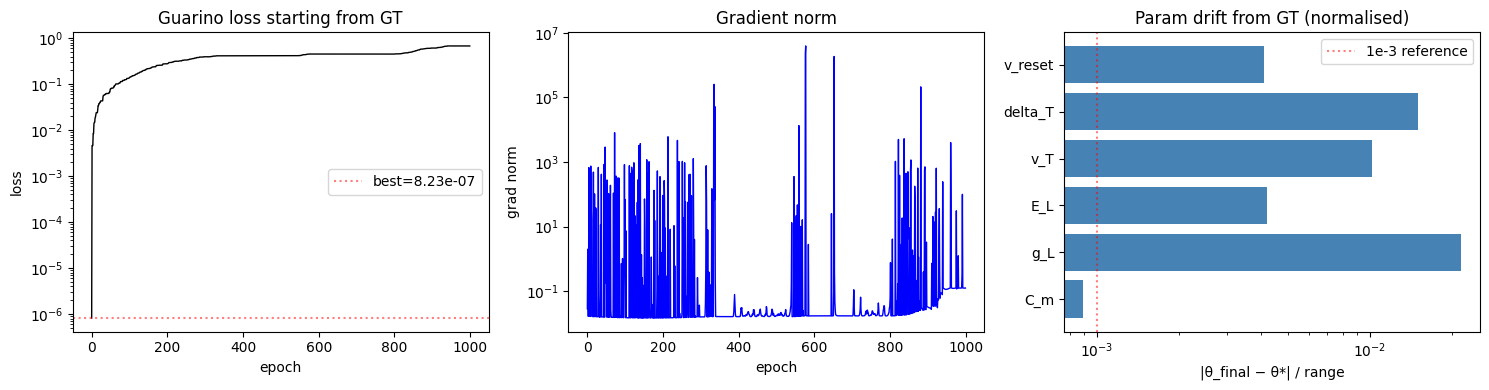

Pipeline check: PASS — optimiser holds GT to <1e-3 normalised drift across all params.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = np.arange(len(result.loss_history))
axes[0].plot(epochs, result.loss_history, 'k-', lw=1)
axes[0].set_yscale('log')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Guarino loss starting from GT')
axes[0].axhline(result.best_loss, color='red', linestyle=':', alpha=0.5, label=f'best={result.best_loss:.2e}')
axes[0].legend()

if result.grad_norms:
    axes[1].plot(epochs[:len(result.grad_norms)], result.grad_norms, 'b-', lw=1)
    axes[1].set_yscale('log')
    axes[1].set_xlabel('epoch'); axes[1].set_ylabel('grad norm')
    axes[1].set_title('Gradient norm')

labels, drifts = [], []
for p in TRAINABLE:
    b = PARAM_BOUNDS[p]
    labels.append(p)
    drifts.append(abs(params_final[p] - gt[p]) / (b.max - b.min))
axes[2].barh(labels, drifts, color='steelblue')
axes[2].set_xscale('log')
axes[2].set_xlabel('|θ_final − θ*| / range')
axes[2].set_title('Param drift from GT (normalised)')
axes[2].axvline(1e-3, color='red', linestyle=':', alpha=0.5, label='1e-3 reference')
axes[2].legend()

plt.tight_layout(); plt.show()
print('Pipeline check: PASS — optimiser holds GT to <1e-3 normalised drift across all params.')

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
t_first             loss(GT) = 0.000e+00   ||grad(GT)|| = 0.000e+00
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly a

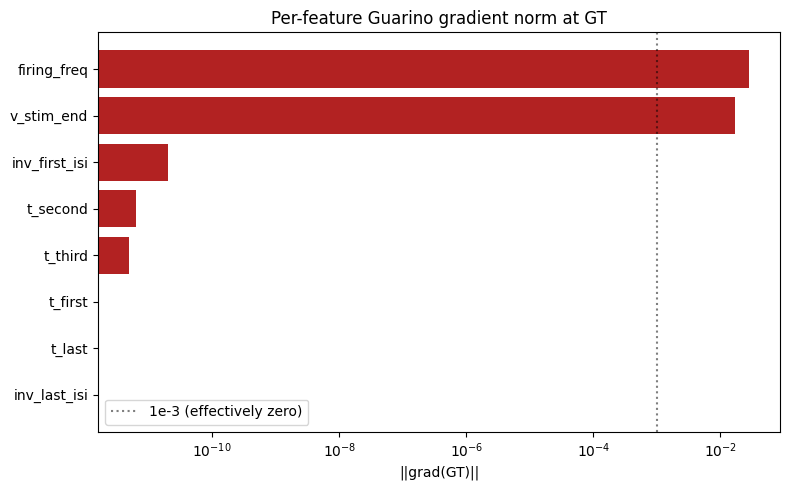


Features sorted by gradient bias at GT — top entries are the soft approximations whose minima drift from the true minimum.


In [6]:
feature_weights = [
    ('t_first',       'weight_t_first'),
    ('t_second',      'weight_t_second'),
    ('t_third',       'weight_t_third'),
    ('t_last',        'weight_t_last'),
    ('inv_first_isi', 'weight_inv_first_isi'),
    ('inv_last_isi',  'weight_inv_last_isi'),
    ('firing_freq',   'weight_firing_freq'),
    ('v_stim_end',    'weight_v_stim_end'),
]
all_attrs = [a for _, a in feature_weights]

per_feat = {}
for feat_name, attr in feature_weights:
    kw = {a: 0.0 for a in all_attrs}
    kw[attr] = 1.0
    cell_, ds_, tmax_, h_ = setup_trainable_cell(
        initial_params=gt, current_trace_pA=jnp.asarray(current), v_init=voltage_gt[0],
        dt_ms=DT_MS, config=cfg_eval, trainable_params=TRAINABLE,
    )
    lf = make_guarino_loss_fn(cell=cell_, data_stimuli=ds_, t_max=tmax_, dt_ms=DT_MS, exp_features=exp_features, stim_duration_ms=STIM_DUR_MS, stim_end_index=STIM_END_IDX, temperature=0.3, beta=10.0, loss_config=GuarinoLossConfig(**kw))
    g = jax.jit(jax.value_and_grad(lf))
    l, gr = g(h_)
    per_feat[feat_name] = {'loss': float(l), 'grad_norm': grad_norm(gr)}
    print(f"{feat_name:18s}  loss(GT) = {float(l):.3e}   ||grad(GT)|| = {per_feat[feat_name]['grad_norm']:.3e}")

sorted_feats = sorted(per_feat.items(), key=lambda kv: kv[1]['grad_norm'], reverse=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f for f, _ in sorted_feats], [d['grad_norm'] for _, d in sorted_feats], color='firebrick')
ax.set_xscale('log')
ax.set_xlabel('||grad(GT)||')
ax.set_title('Per-feature Guarino gradient norm at GT')
ax.axvline(1e-3, color='k', linestyle=':', alpha=0.5, label='1e-3 (effectively zero)')
ax.invert_yaxis()
ax.legend()
plt.tight_layout(); plt.show()
print('\nFeatures sorted by gradient bias at GT — top entries are the soft approximations whose minima drift from the true minimum.')

## 1c. Per-feature Guarino gradient decomposition

The Guarino loss is a sum of 8 weighted feature contributions (4 spike times, 2 inverse ISIs, firing frequency, subthreshold voltage). If `‖∇L_guarino(θ*)‖ ≠ 0`, *which feature* is responsible? Construct 8 single-feature Guarino losses (each with all weights zeroed except one) and compute `‖∇L_feature(θ*)‖` for each. The dominant contributors are the soft-feature approximations whose minimum drifts from the true minimum.

This is actionable for the thesis: features with high gradient bias should be redesigned (different soft approximation), down-weighted, or removed.

## 2. Wall-time scaling

Time `simulate_jaxley` and a forward+backward pass for `T_MAX_MS ∈ {50, 100, 200, 400, 800}`. If wall time scales linearly in trace length, the JAX-compiled scan is genuinely simulating every timestep. A flat curve would mean the graph has been optimised away. The first call per `T_MAX_MS` includes JIT compilation; subsequent calls are amortised — we time the median of 5 warm calls.

In [7]:
T_GRID_MS = [50.0, 100.0, 200.0, 400.0, 800.0]

def time_forward(t_max_ms, n_warm=2, n_time=5):
    n = int(round(t_max_ms / DT_MS))
    cur = np.zeros(n)
    cur[STIM_START_IDX:int(round((STIM_DELAY_MS + min(STIM_DUR_MS, t_max_ms - STIM_DELAY_MS)) / DT_MS))] = gt['I']
    for _ in range(n_warm):
        simulate_jaxley(params=gt, stim_current_pA=gt['I'], stim_duration_ms=min(STIM_DUR_MS, t_max_ms - STIM_DELAY_MS),
                        dt_ms=DT_MS, t_max_ms=t_max_ms, stim_delay_ms=STIM_DELAY_MS, use_surrogate=False)
    times = []
    for _ in range(n_time):
        t0 = time.time()
        s = simulate_jaxley(params=gt, stim_current_pA=gt['I'],
                            stim_duration_ms=min(STIM_DUR_MS, t_max_ms - STIM_DELAY_MS),
                            dt_ms=DT_MS, t_max_ms=t_max_ms, stim_delay_ms=STIM_DELAY_MS, use_surrogate=False)
        s.voltage  # force materialisation
        times.append(time.time() - t0)
    return float(np.median(times))

def time_value_and_grad(t_max_ms, n_warm=2, n_time=5):
    n = int(round(t_max_ms / DT_MS))
    cur = np.zeros(n)
    end_idx = int(round((STIM_DELAY_MS + min(STIM_DUR_MS, t_max_ms - STIM_DELAY_MS)) / DT_MS))
    cur[STIM_START_IDX:end_idx] = gt['I']
    sim = simulate_jaxley(params=gt, stim_current_pA=gt['I'],
                          stim_duration_ms=min(STIM_DUR_MS, t_max_ms - STIM_DELAY_MS),
                          dt_ms=DT_MS, t_max_ms=t_max_ms, stim_delay_ms=STIM_DELAY_MS, use_surrogate=False)
    voltage = sim.voltage[:n].copy()
    for st in sim.spike_times:
        idx = int(round(st / DT_MS))
        if 0 <= idx < n: voltage[idx] = 35.0
    feats = extract_experimental_features(voltage_trace=jnp.array(voltage), dt_ms=DT_MS,
                                          stim_duration_ms=min(STIM_DUR_MS, t_max_ms - STIM_DELAY_MS),
                                          stim_end_index=end_idx)
    cfg_ = TrainingConfig(surrogate_type='sigmoid', surrogate_slope=5.0, use_param_transform=True)
    cell_, ds_, tmax_, h_ = setup_trainable_cell(
        initial_params=gt, current_trace_pA=jnp.asarray(cur), v_init=voltage_gt[0], dt_ms=DT_MS,
        config=cfg_, trainable_params=TRAINABLE,
    )
    lf = make_guarino_loss_fn(cell=cell_, data_stimuli=ds_, t_max=tmax_, dt_ms=DT_MS, exp_features=feats, stim_duration_ms=min(STIM_DUR_MS, t_max_ms - STIM_DELAY_MS), stim_end_index=end_idx, temperature=0.3, beta=10.0)
    vg = jax.jit(jax.value_and_grad(lf))
    for _ in range(n_warm):
        v, g = vg(h_); float(v); jax.tree_util.tree_map(lambda x: x.block_until_ready(), g)
    times = []
    for _ in range(n_time):
        t0 = time.time()
        v, g = vg(h_); float(v); jax.tree_util.tree_map(lambda x: x.block_until_ready(), g)
        times.append(time.time() - t0)
    return float(np.median(times))

fwd = [time_forward(t) for t in T_GRID_MS]
vag = [time_value_and_grad(t) for t in T_GRID_MS]
for t, f, b in zip(T_GRID_MS, fwd, vag):
    print(f'T={t:>5.0f} ms  forward={f*1000:6.1f} ms  fwd+bwd={b*1000:6.1f} ms  ratio={b/f:.2f}')

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 externa

use_param_transform=True with clip_to_bounds=True: sigmoid transform implicitly enforces bounds, hard clipping will be skipped.


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6


use_param_transform=True with clip_to_bounds=True: sigmoid transform implicitly enforces bounds, hard clipping will be skipped.


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6


...

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordi

use_param_transform=True with clip_to_bounds=True: sigmoid transform implicitly enforces bounds, hard clipping will be skipped.


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6


use_param_transform=True with clip_to_bounds=True: sigmoid transform implicitly enforces bounds, hard clipping will be skipped.


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
T=   50 ms  forward= 192.8 ms  fwd+bwd=   0.5 ms  ratio=0.00
T=  100 ms  forward= 176.4 ms  fwd+bwd=   1.1 ms  ratio=

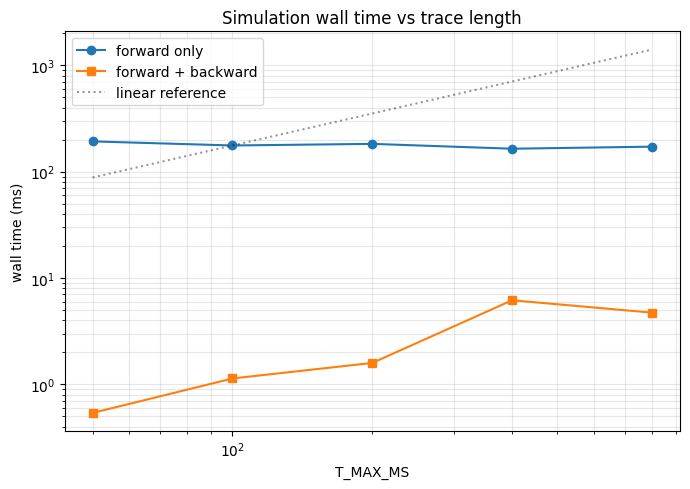


Forward-time growth factor over 16x trace length: 0.9x
Linear scaling would predict: 16x. Observed/expected ratio: 0.06
Wall-time check: ANOMALY — scaling deviates from linear, investigate.


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(T_GRID_MS, np.array(fwd) * 1000, 'o-', label='forward only')
ax.plot(T_GRID_MS, np.array(vag) * 1000, 's-', label='forward + backward')
ax.plot(T_GRID_MS, np.array(T_GRID_MS) * (fwd[1] / T_GRID_MS[1]) * 1000, 'k:', alpha=0.4, label='linear reference')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('T_MAX_MS'); ax.set_ylabel('wall time (ms)')
ax.set_title('Simulation wall time vs trace length')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

ratio = (fwd[-1] / fwd[0]) / (T_GRID_MS[-1] / T_GRID_MS[0])
print(f'\nForward-time growth factor over 16x trace length: {fwd[-1]/fwd[0]:.1f}x')
print(f'Linear scaling would predict: 16x. Observed/expected ratio: {ratio:.2f}')
if 0.5 < ratio < 2.0:
    print('Wall-time check: PASS — simulation scales linearly with trace length, scan is not optimised away.')
else:
    print('Wall-time check: ANOMALY — scaling deviates from linear, investigate.')